<a href="https://colab.research.google.com/github/Yuan-Yu-Han/PTAS/blob/main/final_report_quiz_french_to_english_machine_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Yuan-Yu-Han/PTAS/blob/main/French_to_English_machine_translation_using_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Translation using transformers: Overview

Transformers are a groundbreaking neural network architecture that has significantly advanced the field of natural language processing (NLP), particularly in sequence-to-sequence tasks. They've become the backbone of many modern NLP applications, including machine translation, text summarization, and language modeling.

A defining feature of transformers is their ability to process entire input sequences simultaneously. Unlike traditional recurrent models, which handle one token at a time, transformers leverage a self-attention mechanism to analyze relationships between all elements in a sequence at once. This enables the model to focus on relevant parts of the input context more efficiently and with greater flexibility.

In this tutorial, we'll explore how to build a machine translation system using the transformer architecture.



In [28]:
# ✅ Install required packages with compatible versions for PyTorch-based English-to-French translation.
# Includes torch (with GPU support), torchtext for dataset utilities, spaCy for tokenization,
# and tqdm for progress visualization.


# Remove torchtune (if exist)
!pip uninstall torchtune torchvision torchaudio -y

# Reinstall compatible versions
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0
!pip install torchtext==0.18.0
!pip install 'portalocker>=2.0.0' --no-deps
# !pip install numpy==1.24.3


Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 33.8 MB/s eta 0:00:00


In [6]:
# Confirm the torch version

import torch

torch.__version__

'2.3.0+cu121'

### Loading The Data

In [7]:
import torchtext
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchtext.vocab import build_vocab_from_iterator
from tqdm import tqdm

/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


##### Download the dataset

In [8]:
# !pip install -U kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishreddy18/english-to-french")

print("Path to dataset files:", path)

100%|██████████| 2.50M/2.50M [00:01<00:00, 1.67MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harishreddy18/english-to-french/versions/1


In [9]:
# english_path = '/kaggle/input/english-to-french/small_vocab_en.csv'
# french_path = '/kaggle/input/english-to-french/small_vocab_fr.csv'

english_path = '/root/.cache/kagglehub/datasets/harishreddy18/english-to-french/versions/1/small_vocab_en.csv'
french_path = '/root/.cache/kagglehub/datasets/harishreddy18/english-to-french/versions/1/small_vocab_fr.csv'

with open(english_path, 'r', encoding='utf-8') as f:
    english_sentences = [line.strip() for line in f if line.strip()]

with open(french_path, 'r', encoding='utf-8') as f:
    french_sentences = [line.strip() for line in f if line.strip()]

assert len(english_sentences) == len(french_sentences), \
    f"Mismatch: {len(english_sentences)} vs {len(french_sentences)}"

print(english_sentences[:5])
print(french_sentences[:5])

['new jersey is sometimes quiet during autumn , and it is snowy in april .', 'the united states is usually chilly during july , and it is usually freezing in november .', 'california is usually quiet during march , and it is usually hot in june .', 'the united states is sometimes mild during june , and it is cold in september .', 'your least liked fruit is the grape , but my least liked is the apple .']
["new jersey est parfois calme pendant l' automne , et il est neigeux en avril .", 'les états-unis est généralement froid en juillet , et il gèle habituellement en novembre .', 'california est généralement calme en mars , et il est généralement chaud en juin .', 'les états-unis est parfois légère en juin , et il fait froid en septembre .', 'votre moins aimé fruit est le raisin , mais mon moins aimé est la pomme .']


### Vocabulary Building and Sentence Encoding

This section defines helper functions and builds vocabularies for the English (source) and French (target) datasets.

1. **`yield_tokens`**: A generator function that tokenizes each sentence by lowercasing and splitting on spaces.
2. **Vocabulary Creation**:
   - Uses `build_vocab_from_iterator` to create source (`src_vocab`) and target (`trg_vocab`) vocabularies from tokenized English and French sentences.
   - Adds special tokens: `<pad>` for padding, `<sos>` (start of sentence), and `<eos>` (end of sentence).
   - Sets the default index to the padding token (`<pad>`), which is mapped to index 0.
3. **`encode_sentence`**:
   - Converts a raw sentence into a list of token indices using the corresponding vocabulary.
   - Optionally prepends `<sos>` and appends `<eos>` tokens for use in sequence models.
   - Returns the encoded sentence as a PyTorch tensor.


In [10]:
def yield_tokens(sentences):
    for sentence in sentences:
        yield sentence.strip().lower().split()

SRC_PAD_IDX = 0
TRG_PAD_IDX = 0

src_vocab = build_vocab_from_iterator(yield_tokens(french_sentences), specials=["<pad>", "<sos>", "<eos>"])
src_vocab.set_default_index(SRC_PAD_IDX) # if a token is not found in vocab set it to 0.

trg_vocab = build_vocab_from_iterator(yield_tokens(english_sentences), specials=["<pad>", "<sos>", "<eos>"])
trg_vocab.set_default_index(TRG_PAD_IDX) # if a token is not found in vocab set it to 0.

def encode_sentence(sentence, vocab, add_specials=True):
    tokens = sentence.lower().strip().split()
    if add_specials:
        tokens = ['<sos>'] + tokens + ['<eos>']
    return torch.tensor(vocab(tokens), dtype=torch.long)

In [11]:
print(english_sentences[0])
print(english_sentences[0].lower().strip().split())

print(french_sentences[0])
print(french_sentences[0].lower().strip().split())

new jersey is sometimes quiet during autumn , and it is snowy in april .
['new', 'jersey', 'is', 'sometimes', 'quiet', 'during', 'autumn', ',', 'and', 'it', 'is', 'snowy', 'in', 'april', '.']
new jersey est parfois calme pendant l' automne , et il est neigeux en avril .
['new', 'jersey', 'est', 'parfois', 'calme', 'pendant', "l'", 'automne', ',', 'et', 'il', 'est', 'neigeux', 'en', 'avril', '.']


### Custom Dataset and DataLoader for Machine Translation

This section defines a PyTorch-compatible dataset and a collate function to prepare batches for training a transformer-based translation model.

1. **`TranslationDataset` Class**:
   - Inherits from `torch.utils.data.Dataset`.
   - Takes lists of source (`src`) and target (`trg`) sentences along with their respective vocabularies.
   - Implements `__len__` and `__getitem__`:
     - `__getitem__` encodes each source and target sentence into tensors of token indices using `encode_sentence`.

2. **`collate_fn` Function**:
   - A custom function used to combine individual samples into a batch.
   - Uses `pad_sequence` to pad sequences in the batch so they have equal lengths.
   - Ensures correct padding values (`SRC_PAD_IDX` and `TRG_PAD_IDX`) are used for source and target batches.

3. **`DataLoader` Setup**:
   - Wraps the dataset in a `DataLoader` to enable efficient batch processing.
   - Shuffles data and uses the custom `collate_fn` to handle variable-length sequences.


In [12]:
class TranslationDataset(Dataset):
    def __init__(self, src, trg, src_vocab, trg_vocab):
        self.src = src
        self.trg = trg
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_seq = encode_sentence(self.src[idx], self.src_vocab)
        trg_seq = encode_sentence(self.trg[idx], self.trg_vocab)
        return src_seq, trg_seq

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=SRC_PAD_IDX) # pads the seq to be the same length as the longest sequence
    trg_batch = pad_sequence(trg_batch, padding_value=TRG_PAD_IDX)
    return src_batch, trg_batch

dataset = TranslationDataset(french_sentences, english_sentences, src_vocab, trg_vocab)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)


### Spit into train, val and test set.


In [13]:
from torch.utils.data import random_split

# Split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Total size
dataset = TranslationDataset(french_sentences, english_sentences, src_vocab, trg_vocab)
total_size = len(dataset)

train_size = int(train_ratio * total_size)
val_size = int(val_ratio * total_size)
test_size = total_size - train_size - val_size

# Random split
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


### Positional Encoding Module

This module adds **positional information** to input embeddings, enabling the transformer model to capture the order of tokens in a sequence.

- Uses **sine and cosine functions** of different frequencies to generate position-dependent vectors.
- Applies dropout for regularization.
- The positional encodings are **precomputed and stored** as a buffer to avoid recomputation during training.

The encoding is added to the input embeddings before they are passed into the transformer layers.


### Positional Encoding Formulas

For each position `pos` and embedding dimension `i`, the positional encoding is defined as:

- **Even dimensions** (i = 0, 2, 4, ...):

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

- **Odd dimensions** (i = 1, 3, 5, ...):

$$
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

---

### What this means:

- Each position `pos` has a **unique encoding vector**
- Each dimension `i` corresponds to a **different frequency**
- Sine and cosine allow the model to **recover relative positions**


In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pos_encoding = torch.zeros(max_len, d_model)
        positions = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))

        pos_encoding[:, 0::2] = torch.sin(positions * div_term) # for all 2i
        pos_encoding[:, 1::2] = torch.cos(positions * div_term) # for all 2i + 1

        self.register_buffer('pe', pos_encoding.unsqueeze(1))

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)


### Sequence-to-Sequence Transformer Model

This class defines the core **Transformer-based encoder-decoder architecture** for sequence-to-sequence tasks such as machine translation.

Key components:
- **Embedding Layers**: Convert token indices from the source and target sequences into dense vector representations.
- **Positional Encoding**: Adds position information to the embeddings to help the model understand word order.
- **`nn.Transformer`**: The main transformer block containing multi-head attention, feedforward networks, and residual connections.
  - Configurable number of encoder and decoder layers.
- **Output Generator**: A linear layer that maps the transformer's output to the target vocabulary size for prediction.

The `forward` method takes:
- `src`, `tgt`: Source and target token sequences.
- `src_mask`, `tgt_mask`: Masks to prevent attention to future tokens or pad tokens.
- `src_padding_mask`, `tgt_padding_mask`: Masks to ignore padding in the attention mechanism.

It returns the output logits for the target sequence.


In [15]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_encoder_layers, num_decoder_layers, emb_size, nhead, src_vocab_size, tgt_vocab_size, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.transformer = nn.Transformer(d_model=emb_size, nhead=nhead,
                                          num_encoder_layers=num_encoder_layers,
                                          num_decoder_layers=num_decoder_layers,
                                          dim_feedforward=dim_feedforward,
                                          dropout=dropout)

        self.src_tok_emb = nn.Embedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = nn.Embedding(tgt_vocab_size, emb_size)
        self.positional_encoding = PositionalEncoding(emb_size, dropout=dropout)

        self.generator = nn.Linear(emb_size, tgt_vocab_size)

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask):
        src_emb = self.positional_encoding(self.src_tok_emb(src))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(tgt))
        outs = self.transformer(src_emb, tgt_emb, src_mask, tgt_mask, None,
                                src_padding_mask, tgt_padding_mask, None)
        return self.generator(outs)


### Mask Generation for Transformer

Transformers require masks to control how tokens attend to one another during training, especially for tasks like language modeling and translation. This section defines two functions:

1. **`generate_square_subsequent_mask(sz)`**:
   - Creates an **upper triangular matrix** filled with `-inf` above the diagonal.
   - Prevents the decoder from attending to future tokens during training (auto-regressive behavior).

2. **`create_mask(src, tgt)`**:
   - Generates the necessary masks for both source and target sequences:
     - `src_mask`: A placeholder (all zeros) since the encoder attends to the full input.
     - `tgt_mask`: Prevents the decoder from peeking ahead using `generate_square_subsequent_mask`.
     - `src_padding_mask` and `tgt_padding_mask`: Identify padded positions in the input, so they can be ignored during attention computation.

These masks are passed to the transformer during training and inference to ensure correct attention behavior.


In [16]:
def generate_square_subsequent_mask(sz):
    return torch.triu(
        torch.ones(sz, sz, dtype=torch.bool),
        diagonal=1
    )

def create_mask(src, tgt):
    src_seq_len = src.size(0)
    tgt_seq_len = tgt.size(0)

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len).to(DEVICE)
    src_mask = None

    src_padding_mask = (src == SRC_PAD_IDX).transpose(0, 1)
    tgt_padding_mask = (tgt == TRG_PAD_IDX).transpose(0, 1)

    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

### Training

In [17]:
import torch
import torch.nn as nn
from tqdm import tqdm


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SRC_PAD_IDX = src_vocab['<pad>']
SRC_SOS_IDX = src_vocab['<sos>']
SRC_EOS_IDX = src_vocab['<eos>']

TRG_PAD_IDX = trg_vocab['<pad>']
TRG_SOS_IDX = trg_vocab['<sos>']
TRG_EOS_IDX = trg_vocab['<eos>']

SRC_VOCAB_SIZE = len(src_vocab)
TGT_VOCAB_SIZE = len(trg_vocab)

EMB_SIZE = 512
NHEAD = 4
FFN_HID_DIM = 512
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
BATCH_SIZE = 32
NUM_EPOCHS = 1


model = Seq2SeqTransformer(
    NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE,
    NHEAD, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, FFN_HID_DIM
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# -------------------- Accuracy --------------------
def calculate_accuracy(logits, target):
    pred = logits.argmax(dim=-1)
    non_pad = target != TRG_PAD_IDX
    correct = (pred == target) & non_pad
    return correct.sum().item() / non_pad.sum().item()

# -------------------- history --------------------
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):

    # -------------------- Train --------------------
    model.train()

    train_loss_sum = 0
    train_acc_sum = 0
    train_batches = 0

    for batch_idx, (src, tgt) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} - Train")):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]
        tgt_out   = tgt[1:, :]

        src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_mask(src, tgt_input)

        optimizer.zero_grad()
        logits = model(src, tgt_input,
                       src_mask, tgt_mask,
                       src_pad_mask, tgt_pad_mask)

        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
        loss.backward()
        optimizer.step()

        acc = calculate_accuracy(logits, tgt_out)


        history['train_loss'].append(loss.item())
        history['train_acc'].append(acc)

        # epoch sum
        train_loss_sum += loss.item()
        train_acc_sum += acc
        train_batches += 1

    # epoch average
    train_epoch_loss = train_loss_sum / train_batches
    train_epoch_acc  = train_acc_sum / train_batches


    # -------------------- Validation --------------------
    model.eval()

    val_loss_sum = 0
    val_acc_sum = 0
    val_batches = 0

    for batch_idx, (src, tgt) in enumerate(tqdm(val_loader, desc=f"Epoch {epoch+1} - Val")):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        tgt_input = tgt[:-1, :]
        tgt_out = tgt[1:, :]

        src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_mask(src, tgt_input)

        with torch.no_grad():
            logits = model(src, tgt_input,
                           src_mask, tgt_mask,
                           src_pad_mask, tgt_pad_mask)

            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_out.reshape(-1))
            acc = calculate_accuracy(logits, tgt_out)

            history['val_loss'].append(loss.item())
            history['val_acc'].append(acc)

            val_loss_sum += loss.item()
            val_acc_sum += acc
            val_batches += 1

    val_epoch_loss = val_loss_sum / val_batches
    val_epoch_acc  = val_acc_sum / val_batches


    # -------------------- Epoch Summary --------------------
    print(f"\n📊 Epoch {epoch+1} Summary")
    print(f"Train Loss: {train_epoch_loss:.4f} | Train Acc: {train_epoch_acc:.4f}")
    print(f"Val   Loss: {val_epoch_loss:.4f} | Val   Acc: {val_epoch_acc:.4f}")
    print("-" * 60)

# -------------------- save model --------------------
torch.save(model.state_dict(), "seq2seq_final.pt")
print("✅ Saved final model weights as seq2seq_final.pt")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Epoch 1 - Val: 100%|██████████| 431/431 [00:03<00:00, 117.85it/s]



📊 Epoch 1 Summary
Train Loss: 0.1728 | Train Acc: 0.9512
Val   Loss: 0.0338 | Val   Acc: 0.9802
------------------------------------------------------------
✅ Saved final model weights as seq2seq_final.pt


# Exercises

## Exercise 1: Plot Loss and Accuracy

Plot the training loss and accuracy curves. Compare the training and validation results to see whether they overlap and whether the model is learning well.


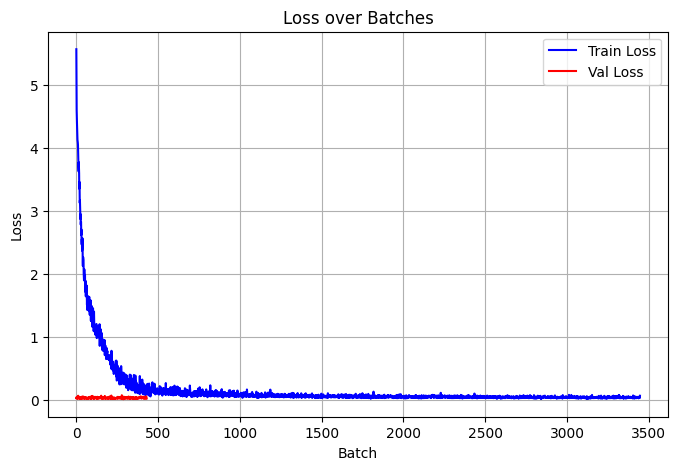

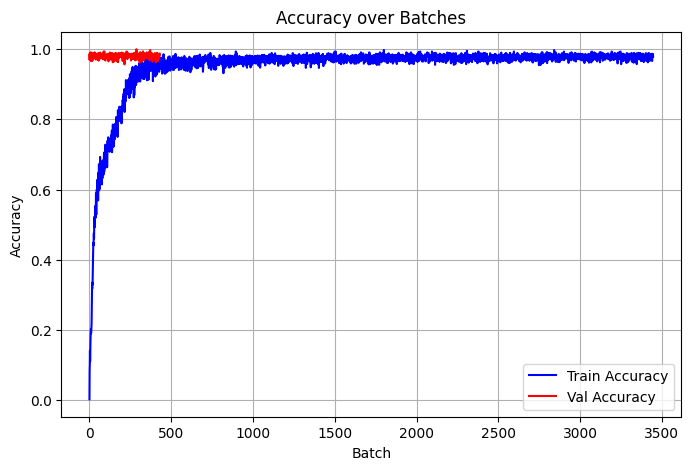

In [18]:
import matplotlib.pyplot as plt

# TO DO
# -------------------- Loss --------------------
plt.figure(figsize=(8,5))
plt.plot(history['train_loss'], 'b-', label='Train Loss')
plt.plot(history['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss over Batches')
plt.legend()
plt.grid(True)
plt.show()

# -------------------- Accuracy --------------------
plt.figure(figsize=(8,5))
plt.plot(history['train_acc'], 'b-', label='Train Accuracy')
plt.plot(history['val_acc'], 'r-', label='Val Accuracy')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Batches')
plt.legend()
plt.grid(True)
plt.show()

## Exercise 2: Check Test Accuracy

Evaluate the model on the test set using greedy decoding, and analyze its overall performance based on the generated outputs.

In [19]:
def greedy_decode(model, src, max_len, start_symbol, return_trace=False, topk=5):
    model.eval()
    src = src.to(DEVICE)

    # ===== Encoder =====
    src_mask = torch.zeros((src.size(0), src.size(0)), device=DEVICE).bool()
    src_padding_mask = (src == SRC_PAD_IDX).transpose(0, 1)

    memory = model.transformer.encoder(
        model.positional_encoding(model.src_tok_emb(src)),
        mask=src_mask,
        src_key_padding_mask=src_padding_mask
    )

    batch_size = src.size(1)
    ys = torch.ones(1, batch_size, device=DEVICE).fill_(start_symbol).long()

    traces = [[] for _ in range(batch_size)] if return_trace else None
    finished = [False] * batch_size if return_trace else None

    for step in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(0)).to(DEVICE)
        tgt_padding_mask = (ys == TRG_PAD_IDX).transpose(0, 1)

        with torch.no_grad():
            out = model.transformer.decoder(
                model.positional_encoding(model.tgt_tok_emb(ys)),
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                memory_key_padding_mask=src_padding_mask
            )

        logits = model.generator(out[-1])
        next_word = logits.argmax(dim=-1)

        if return_trace:
            probs = torch.softmax(logits, dim=-1)
            topk_probs, topk_indices = torch.topk(probs, k=topk, dim=-1)

            for b in range(batch_size):
                if finished[b]:
                    continue
                traces[b].append({
                    'step': step + 1,
                    'chosen_id': int(next_word[b].item()),
                    'topk_ids': topk_indices[b].detach().cpu().tolist(),
                    'topk_probs': topk_probs[b].detach().cpu().tolist(),
                })
                if int(next_word[b].item()) == TRG_EOS_IDX:
                    finished[b] = True

        ys = torch.cat([ys, next_word.unsqueeze(0)], dim=0)

        if return_trace:
            if all(finished):
                break
        else:
            if (next_word == TRG_EOS_IDX).all():
                break

    if return_trace:
        return ys, traces
    return ys


In [20]:
len(test_dataset)

13786

## Exercise 3: Try Different Numbers of Attention Heads

Change the number of attention heads `NHEAD` and evaluate its effect on the model’s performance on the test set.

## Exercise 4: Try Different Embedding Sizes

Modify the embedding size `EMB_SIZE` and analyze how it impacts the model’s performance.

In [21]:
import torch
from torch.utils.data import DataLoader, Subset
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from tqdm import tqdm

# -------------------- Setup --------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SRC_PAD_IDX = src_vocab['<pad>']
SRC_SOS_IDX = src_vocab['<sos>']
SRC_EOS_IDX = src_vocab['<eos>']

TRG_PAD_IDX = trg_vocab['<pad>']
TRG_SOS_IDX = trg_vocab['<sos>']
TRG_EOS_IDX = trg_vocab['<eos>']

itos = trg_vocab.get_itos()
smoothie = SmoothingFunction().method1

# -------------------- Test Subset --------------------
subset_indices = list(range(1000))  # 可改为整个 test set
test_subset = Subset(test_dataset, subset_indices)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

# -------------------- Load Model --------------------
model = Seq2SeqTransformer(
    NUM_ENCODER_LAYERS,
    NUM_DECODER_LAYERS,
    EMB_SIZE,
    NHEAD,
    SRC_VOCAB_SIZE,
    TGT_VOCAB_SIZE,
    FFN_HID_DIM
).to(DEVICE)

model.load_state_dict(torch.load("seq2seq_final.pt"))
model.eval()

# -------------------- Evaluation --------------------
max_len = 100

results = []

# sentence BLEU
total_bleu = 0
total_samples = 0

# token accuracy
correct_tokens = 0
total_tokens = 0

# corpus BLEU
all_references = []
all_hypotheses = []

dataset_index = 0

with torch.no_grad():
    for src, tgt in tqdm(test_loader, desc="Test Set (Autoregressive)"):

        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        # autoregressive decoding
        generated = greedy_decode(model, src, max_len, TRG_SOS_IDX)

        # batch-first
        pred_tokens_batch = generated.transpose(0, 1).tolist()
        target_tokens_batch = tgt.transpose(0, 1).tolist()

        for src_tensor, pred, ref in zip(
            src.transpose(0, 1).tolist(),
            pred_tokens_batch,
            target_tokens_batch
        ):

            # Decode Source
            src_text_list = []
            for tok in src_tensor:
                if tok != SRC_PAD_IDX and tok != SRC_SOS_IDX and tok != SRC_EOS_IDX:
                    src_text_list.append(src_vocab.get_itos()[tok])
            src_text = ' '.join(src_text_list)

            # Clean Prediction
            pred_clean = []
            for tok in pred:
                if tok == TRG_EOS_IDX:
                    break
                if tok != TRG_PAD_IDX and tok != TRG_SOS_IDX:
                    pred_clean.append(itos[tok])
            pred_text = ' '.join(pred_clean)

            # Clean Reference
            ref_clean = []
            for tok in ref:
                if tok != TRG_PAD_IDX and tok != TRG_SOS_IDX and tok != TRG_EOS_IDX:
                    ref_clean.append(itos[tok])
            ref_text = ' '.join(ref_clean)

            # -------------------- Sentence BLEU --------------------
            if len(ref_clean) > 0 and len(pred_clean) > 0:
                bleu = sentence_bleu(
                    [ref_clean],
                    pred_clean,
                    smoothing_function=smoothie
                ) * 100

                total_bleu += bleu
                total_samples += 1

                # for corpus BLEU
                all_references.append([ref_clean])
                all_hypotheses.append(pred_clean)

            else:
                bleu = 0.0

            # -------------------- Token-level Accuracy --------------------
            min_len = min(len(ref_clean), len(pred_clean))
            correct_tokens += sum(
                r == p for r, p in zip(ref_clean[:min_len], pred_clean[:min_len])
            )
            total_tokens += len(ref_clean)

            # -------------------- Save Results --------------------
            results.append({
                "index": subset_indices[dataset_index],  # ⭐ 加上 dataset index
                "src_text": src_text,
                "predicted_text": pred_text,
                "tgt_text": ref_text,
                "bleu_score": bleu
            })

            dataset_index += 1  # ⭐ 每保存一条就加 1

# -------------------- Final Metrics --------------------
avg_sentence_bleu = (total_bleu / total_samples) if total_samples > 0 else 0
token_accuracy = (correct_tokens / total_tokens * 100) if total_tokens > 0 else 0

corpus_bleu_score = corpus_bleu(
    all_references,
    all_hypotheses,
    smoothing_function=smoothie
) * 100

# -------------------- Print Metrics --------------------
print("\n==================== Final Evaluation ====================")
print(f"📊 Sentence BLEU (avg):   {avg_sentence_bleu:.2f}")
print(f"📊 Corpus BLEU:           {corpus_bleu_score:.2f}")
print(f"📊 Token-level Accuracy:  {token_accuracy:.2f}%")
print("==========================================================")

# -------------------- Show First 5 Samples --------------------
print("\n🏆 First 5 Translations:")
for i, r in enumerate(results[:5]):
    print(f"\nSample {i+1}")
    print(f"  📝 Source:    {r['src_text']}")
    print(f"  🤖 Predicted: {r['predicted_text']}")
    print(f"  ✅ Target:    {r['tgt_text']}")
    print(f"  📊 BLEU:      {r['bleu_score']:.2f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:306: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
Test Set (Autoregressive): 100%|██████████| 32/32 [00:33<00:00,  1.06s/it]


==================== Final Evaluation ====================
📊 Sentence BLEU (avg):   89.14
📊 Corpus BLEU:           91.49
📊 Token-level Accuracy:  92.74%

🏆 First 5 Translations:

Sample 1
  📝 Source:    leurs fruits le plus aimé est le pamplemousse , mais votre plus aimé est la pomme .
  🤖 Predicted: their most loved fruit is the grapefruit , but your most loved is the apple .
  ✅ Target:    their most loved fruit is the grapefruit , but your most loved is the apple .
  📊 BLEU:      100.00

Sample 2
  📝 Source:    chine est occupée en mars , mais il est humide en janvier .
  🤖 Predicted: china is busy during march , but it is wet in january .
  ✅ Target:    china is busy during march , but it is wet in january .
  📊 BLEU:      100.00

Sample 3
  📝 Source:    il déteste les pommes , les bananes et les raisins .
  🤖 Predicted: he dislikes apples , bananas , and grapes .
  ✅ Target:    he dislikes apples , bananas , and grapes .
  📊 BLEU:      100.00

Sample 4
  📝 Source:    il aime les 

In [22]:
def ids_to_text(ids, vocab, pad_idx, sos_idx, eos_idx):
    words = []
    for tok in ids:
        if tok == eos_idx:
            break
        if tok not in {pad_idx, sos_idx}:
            words.append(vocab[tok])
    return ' '.join(words)


## Exercise 5: Show Prediction Traces

Show the step-by-step prediction process of the model and analyze the outputs. Suggest possible ways to improve performance.

In [23]:
# sorted in BLEU

# TO DO
results_sorted = sorted(results, key=lambda x: x['bleu_score'], reverse=True)

print("🏆 Top 5 Best Translations:")
for i, r in enumerate(results_sorted[:5]):
    print(f"Sample {i+1}")
    print(f"  📝 Source:    {r['src_text']}")
    print(f"  🤖 Predicted: {r['predicted_text']}")
    print(f"  ✅ Target:    {r['tgt_text']}")
    print(f"  📊 BLEU:      {r['bleu_score']:.2f}\n")


print("\n⚠️ Top 5 Worst Translations:")
for i, r in enumerate(results_sorted[-5:]):
    print(f"Sample {i+1}")
    print(f"  📝 Source:    {r['src_text']}")
    print(f"  🤖 Predicted: {r['predicted_text']}")
    print(f"  ✅ Target:    {r['tgt_text']}")
    print(f"  📊 BLEU:      {r['bleu_score']:.2f}\n")

🏆 Top 5 Best Translations:
Sample 1
  📝 Source:    leurs fruits le plus aimé est le pamplemousse , mais votre plus aimé est la pomme .
  🤖 Predicted: their most loved fruit is the grapefruit , but your most loved is the apple .
  ✅ Target:    their most loved fruit is the grapefruit , but your most loved is the apple .
  📊 BLEU:      100.00

Sample 2
  📝 Source:    chine est occupée en mars , mais il est humide en janvier .
  🤖 Predicted: china is busy during march , but it is wet in january .
  ✅ Target:    china is busy during march , but it is wet in january .
  📊 BLEU:      100.00

Sample 3
  📝 Source:    il déteste les pommes , les bananes et les raisins .
  🤖 Predicted: he dislikes apples , bananas , and grapes .
  ✅ Target:    he dislikes apples , bananas , and grapes .
  📊 BLEU:      100.00

Sample 4
  📝 Source:    il aime les fraises , les poires et les bananes .
  🤖 Predicted: he likes strawberries , pears , and bananas .
  ✅ Target:    he likes strawberries , pears , and ban

In [24]:
import pandas as pd

NUM_SAMPLES = 8
MAX_STEPS = 8
TOPK = 5

def show_trace(indices):

    ex_subset = Subset(test_dataset, indices)

    ex_loader = DataLoader(
        ex_subset,
        batch_size=len(indices),
        shuffle=False,
        collate_fn=collate_fn
    )

    src_ex, tgt_ex = next(iter(ex_loader))

    generated_ex, traces_ex = greedy_decode(
        model, src_ex, max_len=40, start_symbol=TRG_SOS_IDX, topk=TOPK,
        return_trace=True
    )

    src_list  = src_ex.transpose(0,1).tolist()
    tgt_list  = tgt_ex.transpose(0,1).tolist()
    pred_list = generated_ex.transpose(0,1).tolist()

    src_itos = src_vocab.get_itos()

    for i in range(len(indices)):

        src_text  = ids_to_text(src_list[i], src_itos, SRC_PAD_IDX, SRC_SOS_IDX, SRC_EOS_IDX)
        ref_text  = ids_to_text(tgt_list[i], itos, TRG_PAD_IDX, TRG_SOS_IDX, TRG_EOS_IDX)
        pred_text = ids_to_text(pred_list[i], itos, TRG_PAD_IDX, TRG_SOS_IDX, TRG_EOS_IDX)

        print(f"\n{'='*65}")
        print(f"Sample {i+1}")
        print(f"FR :  {src_text}")
        print(f"EN :  {pred_text}")
        print(f"REF:  {ref_text}")
        print()

        steps = traces_ex[i][:MAX_STEPS]

        rows = []
        for s in steps:

            chosen = itos[s['chosen_id']] if s['chosen_id'] < len(itos) else f"<{s['chosen_id']}>"

            row = {"Chosen ✓": chosen}

            for rank, (tid, prob) in enumerate(zip(s['topk_ids'], s['topk_probs']),1):
                tok = itos[tid] if tid < len(itos) else f"<{tid}>"
                row[f"Top-{rank}"] = f"{tok} ({prob:.3f})"

            rows.append(row)

        df = pd.DataFrame(rows, index=[f"step {s['step']}" for s in steps])
        display(df)

        extra = len(traces_ex[i]) - MAX_STEPS
        if extra > 0:
            print(f"... {extra} more steps not shown")


## for certain samples

In [25]:
mode = "worst"
start = None
end = None

# TO DO

if mode == "best":
    indices = [r["index"] for r in results_sorted[:NUM_SAMPLES]]

elif mode == "worst":
    indices = [r["index"] for r in results_sorted[-NUM_SAMPLES:]]

elif start is not None and end is not None:
    indices = list(range(start, end))

else:
    raise ValueError("Please specify mode='best', mode='worst', or start/end.")

show_trace(indices)


Sample 1
FR :  ont -ils comme la chine ?
EN :  the lake china is freezing china ?
REF:  do they like china ?



,Chosen ✓,Top-1,Top-2,Top-3,Top-4,Top-5
step 1,the,the (0.728),china (0.185),california (0.012),france (0.008),lake (0.006)
step 2,lake,lake (0.192),china (0.187),united (0.137),football (0.069),eiffel (0.051)
step 3,china,china (0.800),is (0.049),freezing (0.014),? (0.011),field (0.011)
step 4,is,is (0.511),china (0.423),? (0.012),field (0.005),during (0.002)
step 5,freezing,freezing (0.274),her (0.175),going (0.157),his (0.099),china (0.049)
step 6,china,china (0.641),during (0.327),? (0.006),tower (0.002),to (0.002)
step 7,?,? (0.404),during (0.262),china (0.170),tower (0.035),field (0.018)
step 8,<eos>,<eos> (0.965),? (0.014),during (0.006),tower (0.002),china (0.002)



Sample 2
FR :  pourquoi sont - ils en chine ?
EN :  why china is they china during china ?
REF:  why are they going to china ?



,Chosen ✓,Top-1,Top-2,Top-3,Top-4,Top-5
step 1,why,why (0.789),china (0.065),the (0.043),new (0.016),california (0.005)
step 2,china,china (0.383),are (0.288),did (0.079),aren't (0.051),didn't (0.032)
step 3,is,is (0.728),china (0.093),? (0.028),during (0.020),in (0.012)
step 4,they,they (0.257),never (0.184),going (0.122),rainy (0.102),the (0.058)
step 5,china,china (0.898),during (0.083),going (0.002),go (0.001),lake (0.001)
step 6,during,during (0.780),china (0.126),? (0.046),field (0.005),tower (0.005)
step 7,china,china (0.966),april (0.007),fall (0.005),autumn (0.003),december (0.002)
step 8,?,? (0.782),field (0.041),", (0.034)",tower (0.023),lake (0.012)


... 1 more steps not shown

Sample 3
FR :  elle conduisait la voiture rouillée rouge .
EN :  the rusty red rusty red red red red red red red red red red car .
REF:  she was driving the rusty red automobile .



...

... 8 more steps not shown

Sample 7
FR :  elle conduit la petite voiture jaune .
EN :  the drives is little yellow yellow yellow yellow yellow yellow yellow yellow yellow .
REF:  she drives the little yellow automobile .



,Chosen ✓,Top-1,Top-2,Top-3,Top-4,Top-5
step 1,the,the (0.600),is (0.194),drives (0.057),she (0.038),her (0.024)
step 2,drives,drives (0.394),is (0.380),little (0.076),strawberry (0.016),mango (0.013)
step 3,is,is (0.833),the (0.151),drives (0.007),her (0.001),little (0.001)
step 4,little,little (0.865),her (0.038),never (0.018),driving (0.014),snowy (0.009)
step 5,yellow,yellow (0.999),during (0.000),new (0.000),rusty (0.000),strawberry (0.000)
step 6,yellow,yellow (0.868),automobile (0.048),car (0.045),during (0.008),little (0.003)
step 7,yellow,yellow (0.750),car (0.099),automobile (0.097),during (0.007),. (0.005)
step 8,yellow,yellow (0.623),car (0.158),automobile (0.149),. (0.011),the (0.007)


... 7 more steps not shown

Sample 8
FR :  avez - vous , comme la californie ?
EN :  california is rainy during california , and it is freezing in fall ? ? ? ?
REF:  did you like california ?



,Chosen ✓,Top-1,Top-2,Top-3,Top-4,Top-5
step 1,california,california (0.631),the (0.210),do (0.048),china (0.008),new (0.007)
step 2,is,is (0.560),are (0.109),? (0.062),like (0.047),freezing (0.023)
step 3,rainy,rainy (0.542),you (0.316),your (0.015),going (0.015),wet (0.014)
step 4,during,during (0.977),california (0.019),? (0.001),freezing (0.000),the (0.000)
step 5,california,california (0.933),april (0.011),october (0.007),spring (0.006),fall (0.005)
step 6,",",", (0.492)",? (0.318),field (0.015),lake (0.015),tower (0.011)
step 7,and,and (0.347),but (0.190),? (0.142),california (0.080),field (0.020)
step 8,it,it (0.991),california (0.001),do (0.001),lake (0.001),field (0.000)


... 9 more steps not shown


### 📊 Test Set Performance Visualization


### Checking on samples from test set

### 🎯 Best and Worst Translations


### Exercise 2.2 Evaluation using beam search

In [26]:
import numpy
print(numpy.__version__)
import portalocker
print(portalocker.__version__)

2.0.2
3.2.0


####
To-Do

Q. Visualize results for other samples from the test set

Q. Try different epoch values — e.g., 4, 5, 6 — and observe how the loss changes.

Q. Experiment with different architecture configurations, such as changing the number of encoder and decoder layers.

Q. Try for different batch sizes

Q. We you find a different translation dataset try on that.

### Resources

[The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)


### [Quiz](https://docs.google.com/forms/d/e/1FAIpQLScM0wn9cLVWCQvJemeOWlrK_RhGBmdeKOJBaqFkERFGmyqK3w/viewform?usp=dialog)

In [27]:
# def greedy_decode(model, src, max_len, start_symbol, trace=False, topk=5):
#     """
#     Greedy decoding for seq2seq Transformer.

#     Args:
#         model      : Seq2SeqTransformer
#         src        : (seq_len, batch_size) source tensor
#         max_len    : max decoding steps
#         start_symbol: int, SOS token index
#         trace      : bool, whether to record top-k traces
#         topk       : int, number of top tokens to record if trace=True

#     Returns:
#         ys         : (seq_len, batch_size) predicted token indices
#         traces     : list of dicts (if trace=True), else None
#     """
#     model.eval()
#     src = src.to(DEVICE)

#     src_mask = torch.zeros((src.size(0), src.size(0)), device=DEVICE).bool()
#     src_padding_mask = (src == SRC_PAD_IDX).transpose(0, 1)

#     memory = model.transformer.encoder(
#         model.positional_encoding(model.src_tok_emb(src)),
#         mask=src_mask,
#         src_key_padding_mask=src_padding_mask
#     )

#     batch_size = src.size(1)
#     ys = torch.ones(1, batch_size, device=DEVICE).fill_(start_symbol).long()
#     traces = [[] for _ in range(batch_size)] if trace else None
#     finished = [False] * batch_size

#     for step in range(max_len - 1):
#         tgt_mask = generate_square_subsequent_mask(ys.size(0)).to(DEVICE)
#         tgt_padding_mask = (ys == TRG_PAD_IDX).transpose(0, 1)

#         with torch.no_grad():
#             out = model.transformer.decoder(
#                 model.positional_encoding(model.tgt_tok_emb(ys)),
#                 memory,
#                 tgt_mask=tgt_mask,
#                 tgt_key_padding_mask=tgt_padding_mask,
#                 memory_key_padding_mask=src_padding_mask
#             )

#         logits = model.generator(out[-1])
#         next_word = logits.argmax(dim=-1)

#         if trace:
#             probs = torch.softmax(logits, dim=-1)
#             topk_probs, topk_indices = torch.topk(probs, k=topk, dim=-1)

#             for b in range(batch_size):
#                 if finished[b]:
#                     continue
#                 traces[b].append({
#                     "step": step + 1,
#                     "chosen_id": int(next_word[b].item()),
#                     "topk_ids": topk_indices[b].detach().cpu().tolist(),
#                     "topk_probs": topk_probs[b].detach().cpu().tolist()
#                 })
#                 if int(next_word[b].item()) == TRG_EOS_IDX:
#                     finished[b] = True

#         ys = torch.cat([ys, next_word.unsqueeze(0)], dim=0)

#         if (next_word == TRG_EOS_IDX).all():
#             break

#     if trace:
#         return ys, traces
#     else:
#         return ys

7-8mins in total


Changes:
1. translate from French to English
2. autoregressive generation
3. epoch=2


Exercises:
1. loss/accuracy curve visualization
2. checking the best and worst bleu_score and samples
3. finding top 1




Optional:
1. batch_size num_hidden -- performance didn't change
2. greedy decode vs beam search
3. remove sos eos pad


